In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [114]:
df=pd.read_csv("Mall_Customers.csv")

In [115]:
X=df.iloc[:,2:].values
y=df.iloc[:,1].values

In [116]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [117]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

In [118]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=0.5,min_samples=5)
db_cl=db.fit_predict(X_scaled)

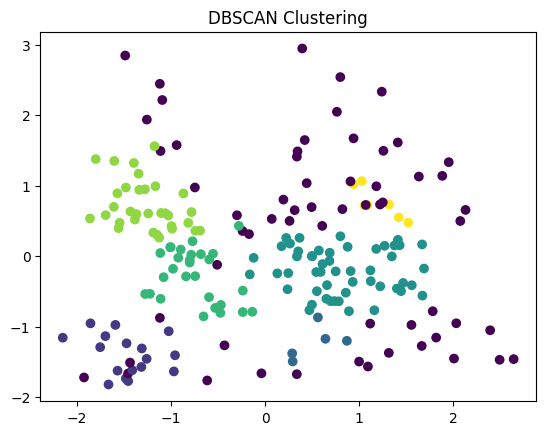

In [119]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=db_cl)
plt.title("DBSCAN Clustering")
plt.show()

In [120]:
from sklearn.metrics import silhouette_score,davies_bouldin_score,adjusted_rand_score,adjusted_mutual_info_score,normalized_mutual_info_score,homogeneity_score,completeness_score,v_measure_score
print("DBSCAN Silhouette:", silhouette_score(X_scaled, db_cl))
print("DBSCAN DB Index:", davies_bouldin_score(X_scaled, db_cl))
print("DBSCAN ARI:", adjusted_rand_score(y, db_cl))
print("DBSCAN NMI:", normalized_mutual_info_score(y, db_cl))
print("DBSCAN Homogeneity:", homogeneity_score(y, db_cl))
print("DBSCAN Completeness:", completeness_score(y, db_cl))
print("DBSCAN V-measure:", v_measure_score(y, db_cl))

DBSCAN Silhouette: 0.18451372756506046
DBSCAN DB Index: 1.7569458461701164
DBSCAN ARI: -0.00745611545027611
DBSCAN NMI: 0.004763551272606337
DBSCAN Homogeneity: 0.008275037968010988
DBSCAN Completeness: 0.0033443757824336766
DBSCAN V-measure: 0.004763551272606337


In [121]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=5,random_state=42)
km_cl=km.fit_predict(X_scaled)

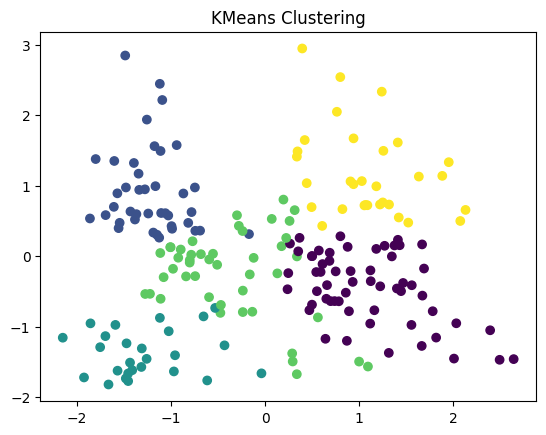

In [122]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_cl)
plt.title("KMeans Clustering")
plt.show()

In [123]:
print("KMeans Silhouette:", silhouette_score(X_scaled, km_cl))
print("KMeans DB Index:", davies_bouldin_score(X_scaled, km_cl))
print("KMeans ARI:", adjusted_rand_score(y, km_cl))
print("KMeans NMI:", normalized_mutual_info_score(y, km_cl))
print("KMeans Homogeneity:", homogeneity_score(y, km_cl))
print("KMeans Completeness:", completeness_score(y, km_cl))
print("KMeans V-measure:", v_measure_score(y, km_cl))

KMeans Silhouette: 0.40846873777345605
KMeans DB Index: 0.8889693268899006
KMeans ARI: -0.005077988460282476
KMeans NMI: 0.0023995733658454363
KMeans Homogeneity: 0.003947147993924184
KMeans Completeness: 0.0017237396405313328
KMeans V-measure: 0.0023995733658454363


In [124]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5)
hc_cl=hc.fit_predict(X_scaled)

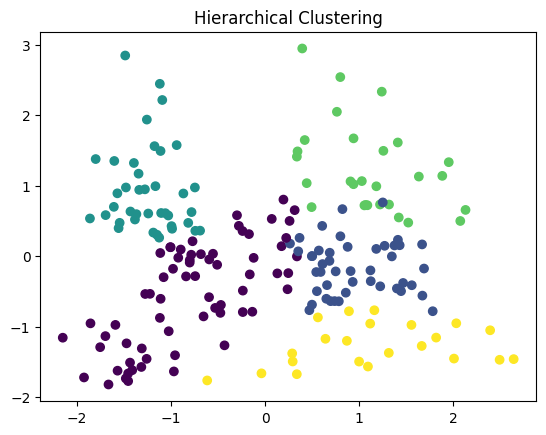

In [125]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_cl)
plt.title("Hierarchical Clustering")
plt.show()

In [126]:
print("Hierarchical Silhouette:", silhouette_score(X_scaled, hc_cl))
print("Hierarchical DB Index:", davies_bouldin_score(X_scaled, hc_cl))
print("Hierarchical ARI:", adjusted_rand_score(y, hc_cl))
print("Hierarchical NMI:", normalized_mutual_info_score(y, hc_cl))
print("Hierarchical Homogeneity:", homogeneity_score(y, hc_cl))
print("Hierarchical Completeness:", completeness_score(y, hc_cl))
print("Hierarchical V-measure:", v_measure_score(y, hc_cl))

Hierarchical Silhouette: 0.39002826186267214
Hierarchical DB Index: 0.9162886109753661
Hierarchical ARI: -0.0027366395886660073
Hierarchical NMI: 0.0028501940295665887
Hierarchical Homogeneity: 0.004621119823213108
Hierarchical Completeness: 0.0020605435129082647
Hierarchical V-measure: 0.002850194029566589


In [127]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

In [128]:
distances = np.sort(distances[:,4])

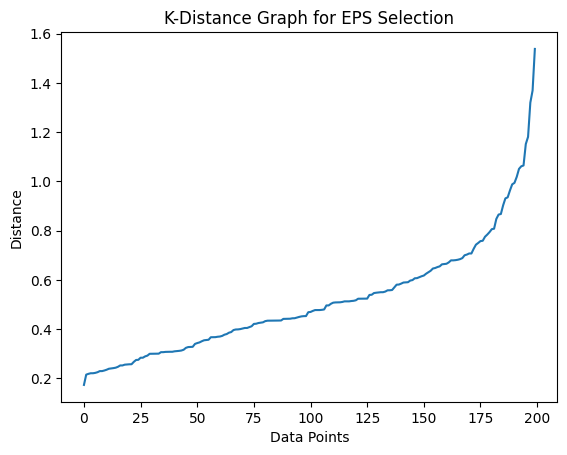

In [129]:
plt.plot(distances)
plt.title("K-Distance Graph for EPS Selection")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [130]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=0.6,min_samples=5)
db_cl=db.fit_predict(X_scaled)

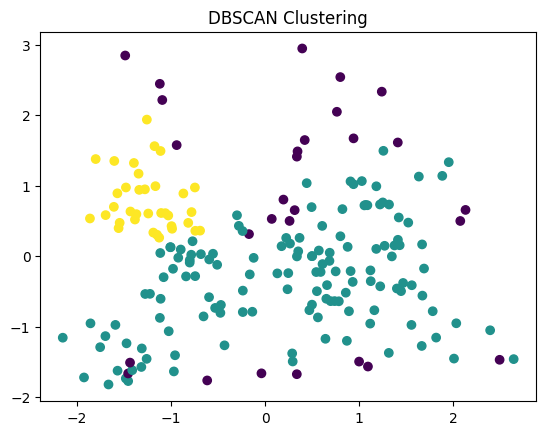

In [131]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=db_cl)
plt.title("DBSCAN Clustering")
plt.show()

In [132]:
print("DBSCAN Silhouette:", silhouette_score(X_scaled, db_cl))
print("DBSCAN DB Index:", davies_bouldin_score(X_scaled, db_cl))
print("DBSCAN ARI:", adjusted_rand_score(y, db_cl))
print("DBSCAN NMI:", normalized_mutual_info_score(y, db_cl))
print("DBSCAN Homogeneity:", homogeneity_score(y, db_cl))
print("DBSCAN Completeness:", completeness_score(y, db_cl))
print("DBSCAN V-measure:", v_measure_score(y, db_cl))

DBSCAN Silhouette: 0.18803828359177516
DBSCAN DB Index: 2.479937262269012
DBSCAN ARI: -0.0040417645500785615
DBSCAN NMI: 0.00019284231002434537
DBSCAN Homogeneity: 0.000214420661753446
DBSCAN Completeness: 0.00017520995159812962
DBSCAN V-measure: 0.0001928423100243454
